# Load and Plot

In [1]:
import tempfile
from pathlib import Path
from typing import List

from matplotlib import pyplot as plt

from pff import config_dir
from pff.config_classes.node_pk_config import NodePKConfig
from pff.data.data_empirical.builder import (
    load_empirical_json_batches_as_dm,
    prediction_to_study_jsons,
)
from pff.data.data_empirical.json_schema import StudyJSON
from pff.data.data_generation.compartment_models_management import (
    prepare_ensemble_of_simulations,
)
from pff.data.datasets.aicme_datasets import (
    AICMECompartmentsDataBatch,
    AICMECompartmentsDataModule,
)
from pff.models.amortized_inference.aicme import AICMEPK
from pff.training.basic_experiment import BasicLightningExperiment
from pff.utils.experiments_potsprocessing import (
    empirical_batches_to_pandas,
    reference_data_nme,
    reference_dict_to_pandas,
)
from pff.utils.plots.databatch_plot import plot_study_json_with_prediction


def _aicme_config_from_file() -> NodePKConfig:
    """Load the default YAML config and shrink it for unit tests."""

    default_yaml = Path(config_dir) / "experiment_configs" / "node-pk" / "base-homogeneous.yaml"
    cfg = NodePKConfig.from_yaml(str(default_yaml))
    return cfg

df_nme = reference_dict_to_pandas(reference_data_nme, model_name="NME", metric_name="log-rmse")

In [2]:
basic_config = _aicme_config_from_file()
experiment = BasicLightningExperiment(experiment_key="8dc3af8d8a5a4653b6dda4a5e8dd185e",model_config=basic_config,train_new=False)
model:AICMEPK = experiment.model
model = model.to("cpu")
experiment_dm: AICMECompartmentsDataModule = experiment.datamodule
experiment_dm.setup()
experiment_dm.fix_past_selection(5)
all_empirical_batches = experiment_dm.get_empirical_test_batches()

Model Config Submitted with Experiment or Model Card
 UPDATING DATAMODULE METADA STUDY CONFIG


CometLogger will be initialized in online mode
COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn, torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/cesarali/aicmepk/8dc3af8d8a5a4653b6dda4a5e8dd185e

Using the latest cached version of the dataset since cesarali/lenuzza-2016 couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at /home/cesarali/.cache/huggingface/datasets/cesarali___lenuzza-2016/default/0.0.0/11946f689431ae2844d6ea61a4da320c1ba10475 (last modified on Mon Sep 22 08:31:02 2025).


In [3]:
empirical_dictionary = experiment_dm.get_empirical_test_batches()
lenuzza_batch_list = empirical_dictionary['cesarali/lenuzza-2016']
one_batch = lenuzza_batch_list[3]
drug_name_index_in_batch  = {name:name_index for name_index,name in enumerate(one_batch.substance_name)}
#drug_name_index_in_batch

In [4]:
sampled_trajectories, sampled_trajectories_time, real_trajectories, mask_real_trajectories  = model.sample_individual_prediction(one_batch,sample_size=10)
study_list = prediction_to_study_jsons(sampled_trajectories, sampled_trajectories_time, one_batch, model.meta_dosing)
drug_name_index = {study["meta_data"]['substance_name']:study_index for study_index,study in enumerate(study_list)}

In [5]:
#drug_name_index

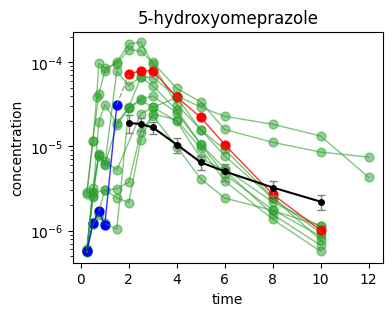

In [6]:
study = study_list[2]
drug_name = study["meta_data"]['substance_name']
fig, ax = plt.subplots(figsize=(4, 3))
ax.set_title(drug_name)
plot_study_json_with_prediction(study, ax=ax, log_scale=True)
plt.show()

# Synthetic

In [7]:
import numpy as np

size_report = {}
size_report_stats = {}
size = 20
for size in range(10,100,10):
    size_report[size] = []
    for i in range(10):
        with tempfile.TemporaryDirectory() as td:
            meta_study = basic_config.meta_study
            meta_study.num_individuals_range = (size, size)
            basic_config.meta_study = meta_study

            tmp_path = Path(td)
            output_path = tmp_path / "ensemble.json"
            number_of_samples = 1
            # CALL THE SIMULATIONS (same positional + kwargs as in the test)
            studies, failure_rate = prepare_ensemble_of_simulations(
                basic_config.meta_study,
                basic_config.context_observations,
                basic_config.dosing,
                number_of_samples=number_of_samples,
                file_name=output_path,
            )

            dm = AICMECompartmentsDataModule(basic_config)

            studies: List[StudyJSON]
            list_databatches: List[AICMECompartmentsDataBatch]
            list_databatches = load_empirical_json_batches_as_dm(
                None, basic_config.dosing, None, experiment_dm, studies
            )

            df_emp_logrmse = empirical_batches_to_pandas(
            all_empirical_batches={"test":list_databatches},
            model=model,
            model_name="AICMEPK",
            metric_name="log_rmse"
            )
            value = df_emp_logrmse.values[0,1]
            size_report[size].append(value)
    size_report_stats[size] = [np.asarray(size_report[size]).mean(),np.asarray(size_report[size]).std()]
    print(size_report_stats[size])


[np.float64(0.5929564920067788), np.float64(0.18345913081808332)]
[np.float64(0.876135561130941), np.float64(0.4054630732947203)]


Invalid simulation encountered during attempt 1 (recursion depth 0); retry_on_invalid=True.
Invalid simulation encountered during attempt 1 (recursion depth 0); retry_on_invalid=True.


[np.float64(0.8426421923687061), np.float64(0.41604259774449504)]


Invalid simulation encountered during attempt 1 (recursion depth 0); retry_on_invalid=True.


[np.float64(0.5710385270416737), np.float64(0.1103481014243378)]
[np.float64(0.7334671151936055), np.float64(0.2179447820854526)]
[np.float64(0.778648482337594), np.float64(0.20020606581465367)]


Invalid simulation encountered during attempt 1 (recursion depth 0); retry_on_invalid=True.
Invalid simulation encountered during attempt 1 (recursion depth 0); retry_on_invalid=True.


[np.float64(0.7363429975828955), np.float64(0.3160813295874844)]


Invalid simulation encountered during attempt 1 (recursion depth 0); retry_on_invalid=True.


[np.float64(0.7248037968575954), np.float64(0.37588198947920365)]
[np.float64(1.1334796803858547), np.float64(0.769404291035718)]


In [13]:
size_report_stats

{10: [np.float64(0.5929564920067788), np.float64(0.18345913081808332)],
 20: [np.float64(0.876135561130941), np.float64(0.4054630732947203)],
 30: [np.float64(0.8426421923687061), np.float64(0.41604259774449504)],
 40: [np.float64(0.5710385270416737), np.float64(0.1103481014243378)],
 50: [np.float64(0.7334671151936055), np.float64(0.2179447820854526)],
 60: [np.float64(0.778648482337594), np.float64(0.20020606581465367)],
 70: [np.float64(0.7363429975828955), np.float64(0.3160813295874844)],
 80: [np.float64(0.7248037968575954), np.float64(0.37588198947920365)],
 90: [np.float64(1.1334796803858547), np.float64(0.769404291035718)]}

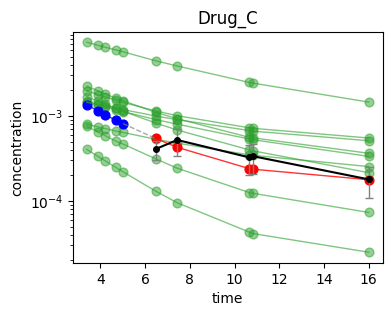

In [8]:
one_batch = list_databatches[0]
sampled_trajectories, sampled_trajectories_time, real_trajectories, mask_real_trajectories  = model.sample_individual_prediction(one_batch,sample_size=10)
study_list = prediction_to_study_jsons(sampled_trajectories, sampled_trajectories_time, one_batch, model.meta_dosing)
study = study_list[0]
drug_name = study["meta_data"]['substance_name']
fig, ax = plt.subplots(figsize=(4, 3))
ax.set_title(drug_name)
plot_study_json_with_prediction(study, ax=ax, log_scale=True)
plt.show()

In [9]:
df_emp_logrmse = empirical_batches_to_pandas(
    all_empirical_batches={"test":list_databatches},
    model=model,
    model_name="AICMEPK",
    metric_name="log_rmse",
)

In [10]:
df_emp_logrmse

,drug,AICMEPK
0,Drug_C,0.433494


# Metrics

In [11]:
df_emp_logrmse = empirical_batches_to_pandas(
    all_empirical_batches={"test":lenuzza_batch_list},
    model=model,
    model_name="AICMEPK",
    metric_name="log_rmse",
)

In [12]:
df_emp_logrmse

,drug,AICMEPK
0,1-hydroxy-midazolam,0.457939
1,4-hydroxy-tolbutamide,0.525734
2,5-hydroxy-omeprazole,1.097226
3,caffeine,0.458930
4,dextromethorphan,0.821558
5,dextrorphan,0.490390
6,digoxin,0.866402
7,hydroxy-repaglinide,0.016727
8,memantine,0.529456
9,midazolam,0.477650
